In [1]:
import pandas as pd
import numpy as np
import sys
sys.path.append("..")

from Src.data_modules import *
from itertools import chain

# Load data

In [2]:
nb_sets = 1
nb_channels = 1
duration = 2
window_size = [1, 0.5]

multitaper_data = get_windowed_multitaper_data(nb_sets=nb_sets, nb_channels=nb_channels, duration=duration, window_size=window_size)

Iteration 1/1


In [6]:
multitaper_data[0][0][0]

array([[33.33959146, 25.53731436, 22.23944005],
       [36.2376834 , 28.52300167, 25.32812386],
       [36.25366758, 28.43735063, 24.76787431],
       [35.97864262, 27.45855353, 24.59921296],
       [33.30937233, 25.630328  , 22.4828569 ],
       [33.26866515, 25.68016895, 22.41652639],
       [32.09713952, 25.08330261, 21.88889585],
       [23.49542045, 21.43352878, 16.59053322],
       [21.14923501, 16.62303331, 16.19963277],
       [16.41731253, 14.61981183, 11.22599479],
       [15.83921708, 13.45670331, 10.69622149],
       [11.64586092, 11.01575587, 10.40993564],
       [11.53064223,  9.31137146,  8.24586516],
       [ 9.92513154,  9.86128017,  8.15836205],
       [10.53302794,  7.96583048,  8.52348591],
       [11.229192  ,  7.78366738,  7.72806109],
       [10.42044078,  7.65922471,  6.53744953],
       [10.43984818,  8.66814229,  6.37876976],
       [ 9.14828654,  7.14607182,  4.2806649 ],
       [ 9.07476116,  6.61802624,  3.99178824],
       [ 8.15468948,  6.49208312,  3.557

In [4]:
len(multitaper_data[0][0])

15425

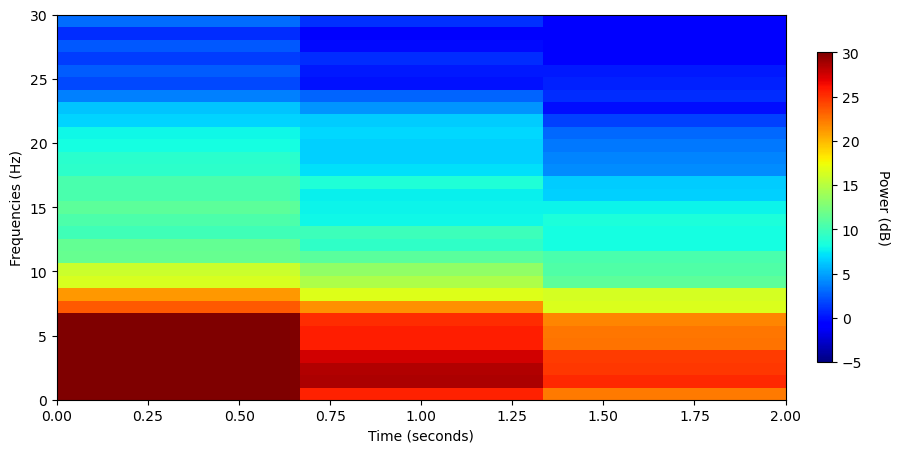

In [5]:
fig, ax = plt.subplots(figsize=(10,5))

cax = ax.imshow(multitaper_data[0][0][0], aspect='auto', vmin=-5, vmax=30, cmap="jet", extent=[0, duration, 30, 0])

cbar = fig.colorbar(cax, ax=ax, orientation='vertical', fraction=0.02, pad=0.04)
cbar.set_label('Power (dB)', rotation=270, labelpad=20)

ax.invert_yaxis()
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Frequencies (Hz)")

plt.show()

In [12]:
multitaper_data = get_channeled_multitaper_data(nb_sets=2, nb_channels=5, window_size=[1, 0.25], type="test")

Set 0/2, iteration 0/26408
Set 0/2, iteration 2/26408
Set 0/2, iteration 4/26408
Set 0/2, iteration 6/26408
Set 0/2, iteration 8/26408
Set 0/2, iteration 10/26408
Set 0/2, iteration 12/26408
Set 0/2, iteration 14/26408
Set 0/2, iteration 16/26408
Set 0/2, iteration 18/26408
Set 0/2, iteration 20/26408
Set 0/2, iteration 22/26408
Set 0/2, iteration 24/26408
Set 0/2, iteration 26/26408
Set 0/2, iteration 28/26408
Set 0/2, iteration 30/26408
Set 0/2, iteration 32/26408
Set 0/2, iteration 34/26408
Set 0/2, iteration 36/26408
Set 0/2, iteration 38/26408
Set 0/2, iteration 40/26408
Set 0/2, iteration 42/26408
Set 0/2, iteration 44/26408
Set 0/2, iteration 46/26408
Set 0/2, iteration 48/26408
Set 0/2, iteration 50/26408
Set 0/2, iteration 52/26408
Set 0/2, iteration 54/26408
Set 0/2, iteration 56/26408
Set 0/2, iteration 58/26408
Set 0/2, iteration 60/26408
Set 0/2, iteration 62/26408
Set 0/2, iteration 64/26408
Set 0/2, iteration 66/26408
Set 0/2, iteration 68/26408
Set 0/2, iteration 70/264

In [13]:
multitaper_data_all = list(chain.from_iterable(multitaper_data))

In [5]:
target_data_all = []

for s in range(4):
    _, target_data = load_train_data(set=s)
    target_data_all += list(target_data.T)

In [11]:
np.savez('multitaper_data_model_31x5.npz', X=multitaper_data_all, y=target_data_all)

In [14]:
np.savez("multitaper_test_data_model_31x5.npz", X=multitaper_data_all)